# 1. Data Collection: SPY (SPDR S&P 500 ETF Trust)

Research pipeline:
`Data_Collection` → `Feature_Engineering` → `HMM_Regime_Detection` → `CNN_LSTM_Attention` → `Backtesting`

This notebook pulls raw daily OHLCV data for **SPY** (and a few auxiliary series that are useful downstream:
**^VIX** for volatility regime context and **^TNX** for the 10Y yield as a macro feature), cleans it,
and persists it to disk.




In [ ]:
!pip install ta
!pip install hmmlearn
!pip install optuna
!pip install -q statsmodels xgboost lightgbm

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import json, os, random
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")


DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

TICKER = "SPY"
START = "1993-01-01"   # long enough to span multiple bull/bear regimes (incl. 2008, 2020)
END = "2026-08-05"


In [ ]:

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

set_seed(SEED)

### 1.1 Download raw OHLCV for SPY

In [ ]:
def download_ohlcv(ticker, start, end=None, interval="1d"):
    df = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=False, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check ticker/date range/network.")
    # yfinance sometimes returns a MultiIndex column header even for a single ticker
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index.name = "Date"
    df = df.rename(columns=str.title)
    return df



### 1.2 Download auxiliary series and merge

In [ ]:
assets = {
    "VIX": "^VIX",
    "TNX": "^TNX",
    "QQQ": "QQQ",
    "IWM": "IWM",
    "TLT": "TLT",
    "GLD": "GLD",
    "USO": "USO",
    "HYG": "HYG",
    "DXY": "DX-Y.NYB"
}

spy_raw = download_ohlcv("SPY", START, END)

df = spy_raw.copy()

for name, ticker in assets.items():
    tmp = download_ohlcv(ticker, START, END)[["Adj Close"]]
    tmp.columns = [name]
    df = df.join(tmp, how="left")

### 1.3 clean and validate

In [ ]:

asset_cols = ["VIX", "TNX", "QQQ", "IWM", "TLT", "GLD", "HYG", "USO", "DXY"]
df[asset_cols] = df[asset_cols].ffill()

# Drop any residual rows where core SPY OHLCV is missing
core_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
before = len(df)
df = df.dropna(subset=core_cols)
after = len(df)
print(f"Dropped {before - after} rows with missing core OHLCV")

# Sanity checks
assert (df["High"] >= df["Low"]).all(), "High < Low detected"
assert (df["Volume"] >= 0).all(), "Negative volume detected"
assert df.index.is_monotonic_increasing, "Index not sorted"
assert not df.index.duplicated().any(), "Duplicate dates found"

df.head()


Dropped 0 rows with missing core OHLCV


,Adj Close,Close,High,Low,Open,Volume,VIX,TNX,QQQ,IWM,TLT,GLD,USO,HYG,DXY
Date,,,,,,,,,,,,,,,
1993-01-29,24.113266,43.93750,43.96875,43.75000,43.96875,1003200,12.42,6.39,NaN,NaN,NaN,NaN,NaN,NaN,92.459999
1993-02-01,24.284771,44.25000,44.25000,43.96875,43.96875,480500,12.33,6.38,NaN,NaN,NaN,NaN,NaN,NaN,93.559998
1993-02-02,24.336222,44.34375,44.37500,44.12500,44.21875,201300,12.25,6.46,NaN,NaN,NaN,NaN,NaN,NaN,93.919998
1993-02-03,24.593473,44.81250,44.84375,44.37500,44.40625,529400,12.12,6.45,NaN,NaN,NaN,NaN,NaN,NaN,94.239998
1993-02-04,24.696369,45.00000,45.09375,44.46875,44.96875,531500,12.29,6.39,NaN,NaN,NaN,NaN,NaN,NaN,94.529999


### 1.4 Quick visual sanity check

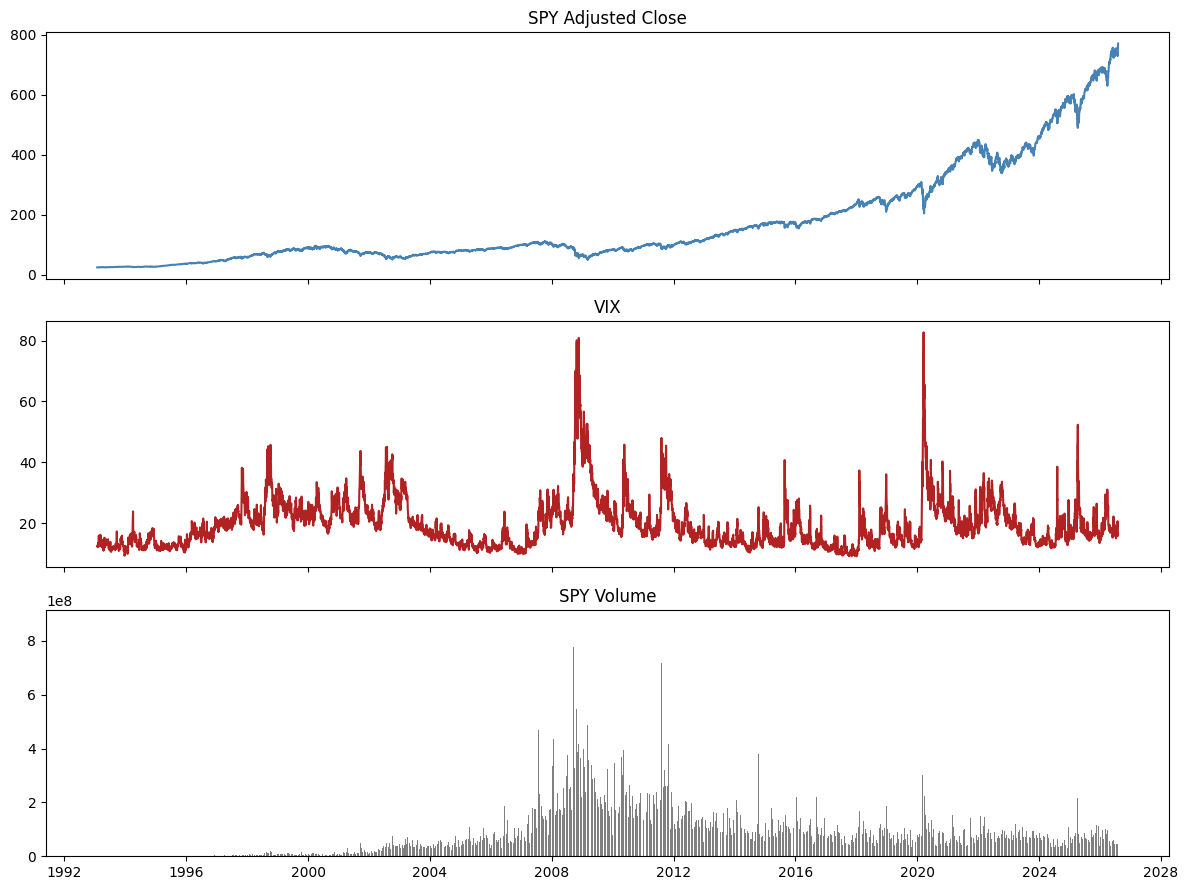

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(df.index, df["Adj Close"], color="steelblue")
axes[0].set_title("SPY Adjusted Close")

axes[1].plot(df.index, df["VIX"], color="firebrick")
axes[1].set_title("VIX")

axes[2].bar(df.index, df["Volume"], color="gray", width=1.0)
axes[2].set_title("SPY Volume")

plt.tight_layout()
plt.show()


### 1.5 Persist raw dataset

In [ ]:
out_path = os.path.join(DATA_DIR, "spy_raw.csv")
df.to_csv(out_path)
print(f"Saved {len(df)} rows to {out_path}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")


Saved 8435 rows to data/spy_raw.csv
Date range: 1993-01-29 -> 2026-08-04


# 2. Feature Engineering:  SPY

Loads `data/spy_raw.csv`  and builds the feature set consumed by
both the HMM regime model and the CNN-LSTM-Attention model:

- Return-based features (log returns, multi-horizon momentum)
- Volatility features (rolling realized vol, ATR, VIX-based)
- Trend/momentum indicators (SMA/EMA, MACD, RSI, ADX)
- Mean-reversion indicators (Bollinger Bands, z-score of price)
- Volume features
- Calendar features



In [ ]:
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_raw.csv"), index_col="Date", parse_dates=True)
df.head()

,Adj Close,Close,High,Low,Open,Volume,VIX,TNX,QQQ,IWM,TLT,GLD,USO,HYG,DXY
Date,,,,,,,,,,,,,,,
1993-01-29,24.113266,43.93750,43.96875,43.75000,43.96875,1003200,12.42,6.39,NaN,NaN,NaN,NaN,NaN,NaN,92.459999
1993-02-01,24.284771,44.25000,44.25000,43.96875,43.96875,480500,12.33,6.38,NaN,NaN,NaN,NaN,NaN,NaN,93.559998
1993-02-02,24.336222,44.34375,44.37500,44.12500,44.21875,201300,12.25,6.46,NaN,NaN,NaN,NaN,NaN,NaN,93.919998
1993-02-03,24.593473,44.81250,44.84375,44.37500,44.40625,529400,12.12,6.45,NaN,NaN,NaN,NaN,NaN,NaN,94.239998
1993-02-04,24.696369,45.00000,45.09375,44.46875,44.96875,531500,12.29,6.39,NaN,NaN,NaN,NaN,NaN,NaN,94.529999


### 2.1 Returns

In [ ]:
px = df["Adj Close"]

df["log_ret_1d"] = np.log(px / px.shift(1))

In [ ]:
# -------- Cross-Asset Returns --------

df=df.rename(columns={"Adj Close": "SPY"})
assets = ["SPY","TNX", "QQQ","IWM","TLT","GLD","HYG", "USO", "DXY"]

for asset in assets:

    df[f"{asset}_ret_5d"] = np.log(
        df[asset] /
        df[asset].shift(5)
    )

In [ ]:
df[["SPY_ret_5d", "TNX_ret_5d", "QQQ_ret_5d", "IWM_ret_5d", "TLT_ret_5d", "GLD_ret_5d", "HYG_ret_5d", "USO_ret_5d", "DXY_ret_5d"]].tail()

,SPY_ret_5d,TNX_ret_5d,QQQ_ret_5d,IWM_ret_5d,TLT_ret_5d,GLD_ret_5d,HYG_ret_5d,USO_ret_5d,DXY_ret_5d
Date,,,,,,,,,
2026-07-29,-0.024309,-0.007544,-0.063837,-0.017928,-0.007096,-0.021435,-0.003527,-0.018162,-0.003367
2026-07-30,0.004744,-0.008542,-0.012228,0.001710,-0.004459,0.015067,0.003025,-0.090033,-0.014099
2026-07-31,0.010902,0.014007,0.005480,0.000103,-0.012085,-0.000968,0.003150,-0.056586,-0.016595
2026-08-03,0.024828,0.009649,0.025975,0.011237,-0.014782,-0.007825,0.005348,-0.021388,-0.015387
2026-08-04,0.040305,0.004983,0.069146,0.028032,-0.012980,0.012885,0.006479,-0.039875,-0.014806


### 2.2 Volatility features

In [ ]:
# Realized volatility (annualized) over rolling windows, from daily log returns
for w in [5, 10, 21, 63]:
    df[f"realized_vol_{w}d"] = df["log_ret_1d"].rolling(w).std() * np.sqrt(252)

# Average True Range (captures intraday range volatility, not just close-to-close)
atr = ta.volatility.AverageTrueRange(high=df["High"], low=df["Low"], close=df["SPY"], window=14)
df["atr_14"] = atr.average_true_range()
df["atr_pct"] = df["atr_14"] / df["SPY"]

# VIX level and its change (market's own vol expectation)
df["vix_level"] = df["VIX"]
df["vix_chg_5d"] = df["VIX"].pct_change(5)

df["vix_ma20"] = (df["VIX"].rolling(20).mean())
df["vix_ratio"] = (df["VIX"] /df["vix_ma20"]-1)
df["vix_chg_1d"] = (df["VIX"].pct_change())

df["tnx_ma20"] = (df["TNX"].rolling(20).mean())
df["tnx_above_ma"] = (df["TNX"] / df["tnx_ma20"]-1)
df["tnx_chg_1d"] = (df["TNX"].pct_change())

### 2.3 Trend and momentum indicators

In [ ]:
df["sma_20"] = ta.trend.sma_indicator(df["SPY"], window=20)
df["sma_50"] = ta.trend.sma_indicator(df["SPY"], window=50)
df["sma_200"] = ta.trend.sma_indicator(df["SPY"], window=200)
df["ema_12"] = ta.trend.ema_indicator(df["SPY"], window=12)
df["ema_26"] = ta.trend.ema_indicator(df["SPY"], window=26)

# Relative Strength
df["spy_vs_qqq"] = (df["SPY"] /df["QQQ"]-1)
df["spy_vs_iwm"] = (df["SPY"] /df["IWM"]-1)
df["spy_vs_tlt"] = (df["SPY"] /df["TLT"]-1)

# Price relative to moving averages (normalized, stationary-ish)
df["px_over_sma50"] = df["SPY"] / df["sma_50"] - 1
df["px_over_sma200"] = df["SPY"] / df["sma_200"] - 1
df["sma50_over_sma200"] = df["sma_50"] / df["sma_200"] - 1   # golden/death cross proxy

macd = ta.trend.MACD(df["SPY"])
df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_diff"] = macd.macd_diff()

df["rsi_14"] = ta.momentum.RSIIndicator(df["SPY"], window=14).rsi()
df["adx_14"] = ta.trend.ADXIndicator(df["High"], df["Low"], df["SPY"], window=14).adx()


### 2.4 Mean-reversion indicators

In [ ]:
bb = ta.volatility.BollingerBands(df["SPY"], window=20, window_dev=2)
df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()
df["bb_pct"] = bb.bollinger_pband()      # 0 = at lower band, 1 = at upper band
df["bb_width"] = bb.bollinger_wband()

# Rolling z-score of price vs its own 20d mean
roll_mean = df["SPY"].rolling(20).mean()
roll_std = df["SPY"].rolling(20).std()
df["price_zscore_20d"] = (df["SPY"] - roll_mean) / roll_std


### 2.5 Volume features

In [ ]:
df["vol_sma_20"] = df["Volume"].rolling(20).mean()
df["vol_ratio_20"] = df["Volume"] / df["vol_sma_20"]
df["obv"] = ta.volume.OnBalanceVolumeIndicator(df["SPY"], df["Volume"]).on_balance_volume()
df["obv_chg_10d"] = df["obv"].pct_change(10)


### 2.6 Calendar features (cyclical encoding)

In [ ]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["month_end"] = (df.index.is_month_end.astype(int))
df["quarter_end"] = (df.index.is_quarter_end.astype(int))


### 2.7 Target variables

Define prediction targets for the CNN-LSTM-Attention model (five-day ahead direction and five-day ahead return).

In [ ]:
df["target_ret_5d_fwd"] = df["SPY_ret_5d"].shift(-5)          # regression target
df["target_dir_5d_fwd"] = (df["target_ret_5d_fwd"] > 0).astype(int)  # classification target


### 2.8 Clean up and inspect

In [ ]:
feature_cols = [c for c in df.columns if c not in
                ["Open", "High", "Low", "Close", "Adj Close", "Volume", "VIX_Close", "TNX",
                 "target_ret_5d_fwd", "target_dir_5d_fwd"]]

print(f"{len(feature_cols)} engineered features")

# Warm-up period (rolling windows up to 200d) produces NaNs at the start; the final row has no forward target
df_feat = df.dropna().copy()
print(f"Rows before dropna: {len(df)}, after: {len(df_feat)}")
df_feat[feature_cols].describe().T


66 engineered features
Rows before dropna: 8435, after: 4850


,count,mean,std,min,25%,50%,75%,max
SPY,4850.0,254.638769,173.739442,49.680580,106.681881,1.890347e+02,376.918060,757.618225
VIX,4850.0,19.897181,8.719294,9.140000,14.200000,1.758000e+01,22.809999,82.690002
QQQ,4850.0,190.617142,170.772751,22.006901,54.067203,1.111486e+02,300.010284,745.340881
IWM,4850.0,124.670933,62.012392,27.184662,66.209324,1.103054e+02,172.724415,300.450012
TLT,4850.0,86.161221,21.195393,45.460949,74.038012,8.564015e+01,96.507113,142.127029
...,...,...,...,...,...,...,...,...
dow_cos,4850.0,-0.015552,0.701733,-0.809017,-0.809017,3.090170e-01,0.309017,1.000000
month_sin,4850.0,-0.007626,0.705313,-1.000000,-0.866025,-2.449294e-16,0.500000,1.000000
month_cos,4850.0,-0.021592,0.708671,-1.000000,-0.866025,-1.836970e-16,0.500000,1.000000
month_end,4850.0,0.033402,0.179703,0.000000,0.000000,0.000000e+00,0.000000,1.000000


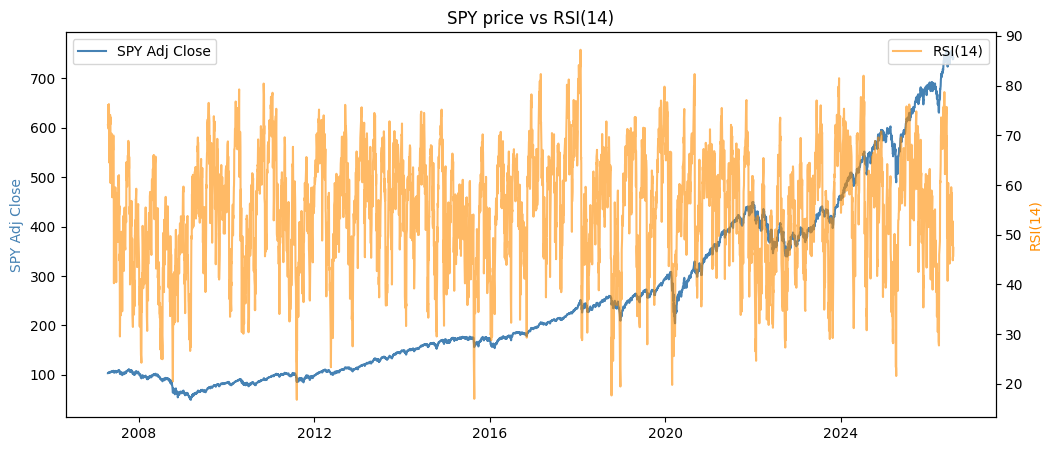

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
ax.plot(df_feat.index, df_feat["SPY"], color="steelblue", label="SPY Adj Close")
ax2.plot(df_feat.index, df_feat["rsi_14"], color="darkorange", alpha=0.6, label="RSI(14)")
ax.set_ylabel("SPY Adj Close", color="steelblue")
ax2.set_ylabel("RSI(14)", color="darkorange")
ax.set_title("SPY price vs RSI(14)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


### 2.9 Persist engineered dataset

In [ ]:
out_path = os.path.join(DATA_DIR, "spy_features.csv")
df_feat.to_csv(out_path)

meta = {"feature_cols": feature_cols,
        "target_cols": ["target_ret_5d_fwd", "target_dir_5d_fwd"]}
import json
with open(os.path.join(DATA_DIR, "feature_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved {len(df_feat)} rows x {df_feat.shape[1]} cols -> {out_path}")


Saved 4850 rows x 74 cols -> data/spy_features.csv


# 3. HMM Regime Detection: SPY

Fits a Gaussian Hidden Markov Model on return and volatility features to identify latent
market regimes (e.g. "low-volatility: bull", "high-volatility bear", "choppy/neutral"), then labels each day in the
dataset with its most likely regime. These regime labels are later fed into the CNN-LSTM-Attention model
as an additional input feature, and used as a filter in the backtest.


In [ ]:
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_features.csv"), index_col="Date", parse_dates=True)

with open(os.path.join(DATA_DIR, "feature_meta.json")) as f:
    meta = json.load(f)

df.tail()

,SPY,Close,High,Low,Open,Volume,VIX,TNX,QQQ,IWM,...,day_of_week,month,dow_sin,dow_cos,month_sin,month_cos,month_end,quarter_end,target_ret_5d_fwd,target_dir_5d_fwd
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-22,747.409973,747.409973,750.020020,746.369995,746.619995,32836200,16.639999,4.657,705.349976,293.790009,...,2,7,0.587785,-0.809017,-0.5,-0.866025,0,0,-0.024309,0
2026-07-23,738.179993,738.179993,742.559998,735.210022,739.369995,55437300,18.700001,4.703,691.960022,292.089996,...,3,7,-0.587785,-0.809017,-0.5,-0.866025,0,0,0.004744,1
2026-07-24,738.929993,738.929993,743.719971,737.289978,738.510010,44782000,18.580000,4.679,684.229980,291.170013,...,4,7,-0.951057,0.309017,-0.5,-0.866025,0,0,0.010902,1
2026-07-27,739.090027,739.090027,745.530029,735.869995,744.909973,41461200,18.670000,4.641,682.119995,292.910004,...,0,7,0.000000,1.000000,-0.5,-0.866025,0,0,0.024828,1
2026-07-28,740.859985,740.859985,742.789978,735.979980,739.190002,47322200,18.209999,4.604,675.489990,293.369995,...,1,7,0.951057,0.309017,-0.5,-0.866025,0,0,0.040305,1


In [ ]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train: {train_df.index.min().date()} -> {train_df.index.max().date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index.min().date()} -> {val_df.index.max().date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index.min().date()} -> {test_df.index.max().date()} ({len(test_df)} rows)")


Train: 2007-04-18 -> 2020-10-08 (3395 rows)
Val:   2020-10-09 -> 2023-08-30 (727 rows)
Test:  2023-08-31 -> 2026-07-28 (728 rows)


### 3.1 Choose HMM input features

HMMs are sensitive to high-dimensional, collinear inputs.
Return and volatility features are the classic choice for regime detection.


In [ ]:
hmm_features = ["SPY_ret_5d", "TNX_ret_5d", "QQQ_ret_5d", "IWM_ret_5d", "TLT_ret_5d", "GLD_ret_5d", "HYG_ret_5d", "USO_ret_5d", "DXY_ret_5d",
                "realized_vol_21d", "vix_level"]

train_X = train_df[hmm_features].values

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_X)
train_scaled.shape


(3395, 11)

### 3.2 Fit Gaussian HMM

We use 3 hidden states as a starting point: intuitively bull / bear / neutral-choppy.

In [ ]:
N_STATES = 3

model = GaussianHMM(
    n_components=N_STATES,
    covariance_type="full",
    n_iter=1000,
    random_state=SEED,
    tol=1e-4,
)
model.fit(train_scaled)

print("Converged:", model.monitor_.converged)
print("Log-likelihood:", model.score(train_scaled))


Converged: True
Log-likelihood: -26799.21436417861


### 3.3 Decode hidden states and order-label them by mean return

In [ ]:
hidden_states = model.predict(train_scaled)

train_df["hmm_state_raw"] = hidden_states

val_df["hmm_state_raw"] = model.predict(
    scaler.transform(val_df[hmm_features])
)

test_df["hmm_state_raw"] = model.predict(
    scaler.transform(test_df[hmm_features])
)

# Raw state indices from hmmlearn are arbitrary — relabel by mean 1d return so labels are consistent
# and interpretable: 0 = bear, 1 = neutral, 2 = bull (ascending mean return)
state_stats = train_df.groupby("hmm_state_raw")["SPY_ret_5d"].agg(["mean", "std", "count"])
state_stats = state_stats.sort_values("mean")
print(state_stats)

order = state_stats.index.tolist()  # ascending mean return
relabel_map = {raw_state: new_label for new_label, raw_state in enumerate(order)}
label_names = {0: "Bear", 1: "Neutral", 2: "Bull"} if N_STATES == 3 else \
              {i: f"Regime_{i}" for i in range(N_STATES)}

train_df["hmm_state"] = train_df["hmm_state_raw"].map(relabel_map)
val_df["hmm_state"] = val_df["hmm_state_raw"].map(relabel_map)
test_df["hmm_state"] = test_df["hmm_state_raw"].map(relabel_map)

train_df["hmm_regime"] = train_df["hmm_state"].map(label_names)
val_df["hmm_regime"] = val_df["hmm_state"].map(label_names)
test_df["hmm_regime"] = test_df["hmm_state"].map(label_names)

df = pd.concat(
    [train_df, val_df, test_df]
).sort_index()

df[["SPY_ret_5d", "realized_vol_21d", "vix_level", "hmm_state", "hmm_regime"]].tail(10)


                   mean       std  count
hmm_state_raw                           
0             -0.008720  0.060567    311
1              0.001270  0.025462   1365
2              0.003826  0.012439   1719


,SPY_ret_5d,realized_vol_21d,vix_level,hmm_state,hmm_regime
Date,,,,,
2026-07-15,0.012545,0.136621,15.670000,2,Bull
2026-07-16,-0.001318,0.124188,16.730000,2,Bull
2026-07-17,-0.015565,0.127262,18.770000,2,Bull
2026-07-20,-0.009495,0.119402,18.650000,2,Bull
2026-07-21,-0.004733,0.117413,17.049999,2,Bull
2026-07-22,-0.009852,0.116921,16.639999,2,Bull
2026-07-23,-0.016845,0.113605,18.700001,1,Neutral
2026-07-24,-0.005883,0.113596,18.580000,1,Neutral
2026-07-27,-0.004051,0.113529,18.670000,1,Neutral


### 3.4 Regime statistics

In [ ]:
regime_summary = df.groupby("hmm_regime")["log_ret_1d"].agg(
    mean_daily_ret="mean",
    ann_ret=lambda x: x.mean() * 252,
    ann_vol=lambda x: x.std() * np.sqrt(252),
    n_days="count",
)
regime_summary["sharpe"] = regime_summary["ann_ret"] / regime_summary["ann_vol"]
regime_summary


,mean_daily_ret,ann_ret,ann_vol,n_days,sharpe
hmm_regime,,,,,
Bear,-0.00128,-0.322477,0.472226,403,-0.682887
Bull,0.00076,0.191454,0.098698,2268,1.939802
Neutral,0.00035,0.088241,0.187168,2179,0.471455


### 3.5 Regime persistence: transition matrix

In [ ]:
trans_df = pd.DataFrame(model.transmat_)  # kept simple


# Simpler, robust approach: rebuild transition matrix directly in *relabeled* state space
n = N_STATES
trans_relabeled = np.zeros((n, n))
raw_seq = df["hmm_state_raw"].values
lab_seq = df["hmm_state"].values

for t in range(len(lab_seq) - 1):
    trans_relabeled[lab_seq[t], lab_seq[t+1]] += 1
trans_relabeled = trans_relabeled / trans_relabeled.sum(axis=1, keepdims=True)

trans_df = pd.DataFrame(trans_relabeled,
                         index=[label_names[i] for i in range(n)],
                         columns=[label_names[i] for i in range(n)])
print("Transition probabilities (row -> col):")
trans_df.round(3)


Transition probabilities (row -> col):


,Bear,Neutral,Bull
Bear,0.928,0.069,0.002
Neutral,0.012,0.968,0.020
Bull,0.001,0.019,0.980


### 3.6 Visualize regimes over the price series

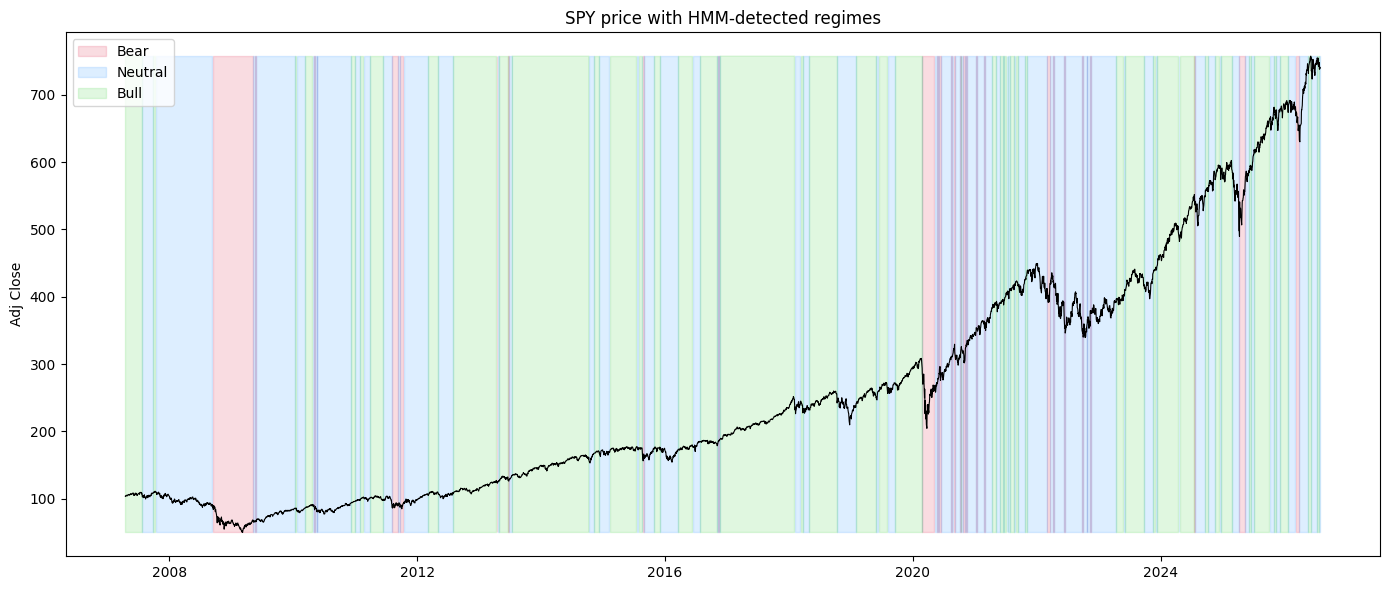

In [ ]:
colors = {"Bear": "crimson", "Neutral": "dodgerblue", "Bull": "limegreen"}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["SPY"], color="black", linewidth=0.8, zorder=3)

for regime, color in colors.items():
    mask = df["hmm_regime"] == regime
    ax.fill_between(df.index, df["SPY"].min(), df["SPY"].max(),
                     where=mask, color=color, alpha=0.15, label=regime, step="mid")

ax.set_title("SPY price with HMM-detected regimes")
ax.set_ylabel("Adj Close")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 3.7 Model selection sanity check: score across different state counts (BIC-style)

In [ ]:
results = []
for k in [2, 3, 4, 5]:
    m = GaussianHMM(n_components=k, covariance_type="full", n_iter=1000, random_state=SEED)
    m.fit(train_scaled)
    ll = m.score(train_scaled)
    n_params = (k-1) + k * (k - 1) + k * train_scaled.shape[1] + k * train_scaled.shape[1] * (train_scaled.shape[1] + 1) / 2
    bic = -2 * ll + n_params * np.log(len(train_scaled))
    results.append({"n_states": k, "log_likelihood": ll, "BIC": bic})

pd.DataFrame(results)


,n_states,log_likelihood,BIC
0,2,-29783.305595,60843.030459
1,3,-26803.947475,55550.979061
2,4,-25351.394831,53328.798732
3,5,-25296.811270,53918.816687


### 3.8 Persist regime-labeled dataset and model artifacts

In [ ]:
out_path = os.path.join(DATA_DIR, "spy_features_regimes.csv")
df.to_csv(out_path)

import pickle
with open(os.path.join(DATA_DIR, "hmm_model.pkl"), "wb") as f:
    pickle.dump({"model": model, "scaler": scaler, "hmm_features": hmm_features,
                 "relabel_map": relabel_map, "label_names": label_names}, f)

print(f"Saved {len(df)} rows -> {out_path}")
print("Saved HMM model -> data/hmm_model.pkl")


Saved 4850 rows -> data/spy_features_regimes.csv
Saved HMM model -> data/hmm_model.pkl


# 4. CNN-LSTM-Attention Model: SPY Next-Day Direction / Return

Builds a hybrid deep learning model:

`1D-CNN (local pattern extraction)` → `LSTM (temporal dependencies)` → `Additive Attention (focus on
informative timesteps)` → `Dense head (prediction)`

Inputs are sliding windows of engineered features (including the HMM regime label as a one-hot feature).
The model is trained to predict **five-day ahead direction** (classification) with an auxiliary **five-day
return** regression head.


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "spy_features_regimes.csv"), index_col="Date", parse_dates=True)

with open(os.path.join(DATA_DIR, "feature_meta.json")) as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
print(f"{len(feature_cols)} base features + hmm_state one-hot")
df.tail()


Using device: cpu
66 base features + hmm_state one-hot


,SPY,Close,High,Low,Open,Volume,VIX,TNX,QQQ,IWM,...,dow_cos,month_sin,month_cos,month_end,quarter_end,target_ret_5d_fwd,target_dir_5d_fwd,hmm_state_raw,hmm_state,hmm_regime
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-22,747.409973,747.409973,750.020020,746.369995,746.619995,32836200,16.639999,4.657,705.349976,293.790009,...,-0.809017,-0.5,-0.866025,0,0,-0.024309,0,2,2,Bull
2026-07-23,738.179993,738.179993,742.559998,735.210022,739.369995,55437300,18.700001,4.703,691.960022,292.089996,...,-0.809017,-0.5,-0.866025,0,0,0.004744,1,1,1,Neutral
2026-07-24,738.929993,738.929993,743.719971,737.289978,738.510010,44782000,18.580000,4.679,684.229980,291.170013,...,0.309017,-0.5,-0.866025,0,0,0.010902,1,1,1,Neutral
2026-07-27,739.090027,739.090027,745.530029,735.869995,744.909973,41461200,18.670000,4.641,682.119995,292.910004,...,1.000000,-0.5,-0.866025,0,0,0.024828,1,1,1,Neutral
2026-07-28,740.859985,740.859985,742.789978,735.979980,739.190002,47322200,18.209999,4.604,675.489990,293.369995,...,0.309017,-0.5,-0.866025,0,0,0.040305,1,1,1,Neutral


### 4.1 Add regime one-hot encoding to the feature set

In [ ]:
train_regime = pd.get_dummies(train_df["hmm_state"], prefix="regime").astype(float)
val_regime = pd.get_dummies(val_df["hmm_state"], prefix="regime").astype(float)
test_regime = pd.get_dummies(test_df["hmm_state"], prefix="regime").astype(float)

expected_cols = ["regime_0", "regime_1", "regime_2"]

train_regime = train_regime.reindex(columns=expected_cols, fill_value=0)
val_regime   = val_regime.reindex(columns=expected_cols, fill_value=0)
test_regime  = test_regime.reindex(columns=expected_cols, fill_value=0)

train_df = pd.concat([train_df, train_regime], axis=1)
val_df   = pd.concat([val_df, val_regime], axis=1)
test_df  = pd.concat([test_df, test_regime], axis=1)

model_feature_cols = feature_cols + expected_cols
print(f"Total model input features: {len(model_feature_cols)}")


Total model input features: 69


### 4.2 Chronological train / validation / test split

No shuffling across the split boundary, and the scaler is fit on train only
to avoid lookahead bias.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_df[model_feature_cols])

def scale(d):
    out = d.copy()
    out[model_feature_cols] = scaler.transform(d[model_feature_cols])
    return out

train_s, val_s, test_s = scale(train_df), scale(val_df), scale(test_df)


### 4.2b Diagnostic: signal check *before* training the deep model

**Class balance**: if the model's test accuracy roughly equals the % of up-days, it's likely just predicting the majority class every time.

In [ ]:
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    up_pct = d["target_dir_5d_fwd"].mean()
    print(f"{name:6s} | up-day rate: {up_pct:.3f}  ({int(d['target_dir_5d_fwd'].sum())}/{len(d)} days)")


Train  | up-day rate: 0.598  (2031/3395 days)
Val    | up-day rate: 0.580  (422/727 days)
Test   | up-day rate: 0.624  (454/728 days)


**Feature information coefficient (IC)**

In [ ]:
from scipy.stats import pointbiserialr

ic_rows = []
for col in model_feature_cols:
    x = train_df[col].values
    y_ret = train_df["target_ret_5d_fwd"].values
    y_dir = train_df["target_dir_5d_fwd"].values

    valid = ~(np.isnan(x) | np.isnan(y_ret))
    ic_ret = np.corrcoef(x[valid], y_ret[valid])[0, 1] if valid.sum() > 1 else np.nan

    try:
        ic_dir, _ = pointbiserialr(y_dir[valid], x[valid])
    except Exception:
        ic_dir = np.nan

    ic_rows.append({"feature": col, "IC_vs_return": ic_ret, "IC_vs_direction": ic_dir})

ic_df = pd.DataFrame(ic_rows).set_index("feature")
ic_df["abs_IC_vs_return"] = ic_df["IC_vs_return"].abs()
ic_df = ic_df.sort_values("abs_IC_vs_return", ascending=False)

print(f"Mean |IC| vs return across all {len(ic_df)} features: {ic_df['abs_IC_vs_return'].mean():.4f}")
print(f"Max  |IC| vs return: {ic_df['abs_IC_vs_return'].max():.4f}  (feature: {ic_df['abs_IC_vs_return'].idxmax()})")
print()
ic_df.drop(columns="abs_IC_vs_return").head(15)


Mean |IC| vs return across all 69 features: 0.0300
Max  |IC| vs return: 0.1069  (feature: atr_14)



,IC_vs_return,IC_vs_direction
feature,,
atr_14,-0.106872,-0.093363
USO,-0.099967,-0.104834
tnx_ma20,-0.090925,-0.103006
log_ret_1d,-0.077606,-0.020045
TLT,0.067035,0.091209
spy_vs_qqq,-0.065808,-0.081818
SPY_ret_5d,-0.064063,-0.013789
GLD,0.063332,0.071558
realized_vol_5d,-0.057710,-0.037956


### 4.3 Build sliding-window sequences

In [ ]:
SEQ_LEN = 60  # lookback window (trading days)

def make_sequences(d, feature_cols, seq_len):
    X_feat = d[feature_cols].values.astype(np.float32)
    y_dir = d["target_dir_5d_fwd"].values.astype(np.float32)
    y_ret = d["target_ret_5d_fwd"].values.astype(np.float32)
    dates = d.index

    X_seq, y_dir_seq, y_ret_seq, date_seq = [], [], [], []
    for i in range(seq_len, len(d)):
        X_seq.append(X_feat[i - seq_len:i])
        y_dir_seq.append(y_dir[i])
        y_ret_seq.append(y_ret[i])
        date_seq.append(dates[i])

    return (np.array(X_seq), np.array(y_dir_seq), np.array(y_ret_seq), np.array(date_seq))

X_train, ydir_train, yret_train, dates_train = make_sequences(train_s, model_feature_cols, SEQ_LEN)
X_val, ydir_val, yret_val, dates_val = make_sequences(val_s, model_feature_cols, SEQ_LEN)
X_test, ydir_test, yret_test, dates_test = make_sequences(test_s, model_feature_cols, SEQ_LEN)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (3335, 60, 69)  Val: (667, 60, 69)  Test: (668, 60, 69)


In [ ]:
class SeqDataset(Dataset):
    def __init__(self, X, y_dir, y_ret):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_dir = torch.tensor(y_dir, dtype=torch.float32)
        self.y_ret = torch.tensor(y_ret, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_dir[idx], self.y_ret[idx]

g = torch.Generator()
g.manual_seed(SEED)

BATCH_SIZE = 64
train_loader = DataLoader(SeqDataset(X_train, ydir_train, yret_train), batch_size=BATCH_SIZE, shuffle=True, generator=g,
                          num_workers=0)
val_loader = DataLoader(SeqDataset(X_val, ydir_val, yret_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(SeqDataset(X_test, ydir_test, yret_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)




### 4.4 Model: CNN → LSTM → Additive Attention → Dual head

In [ ]:
class AdditiveAttention(nn.Module):
    """Bahdanau-style additive attention over LSTM outputs."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden_dim)
        scores = self.v(torch.tanh(self.attn(lstm_out)))          # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)                    # (batch, seq_len, 1)
        context = torch.sum(weights * lstm_out, dim=1)            # (batch, hidden_dim)
        return context, weights.squeeze(-1)                       # context, attention weights


class CNNLSTMAttention(nn.Module):
    def __init__(self, n_features, cnn_channels=64, lstm_hidden=64, lstm_layers=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, cnn_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.conv2 = nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(cnn_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.attention = AdditiveAttention(lstm_hidden)

        self.head_dir = nn.Sequential(
            nn.Linear(lstm_hidden, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
        self.head_ret = nn.Sequential(
            nn.Linear(lstm_hidden, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features) -> Conv1d expects (batch, channels, seq_len)
        x = x.transpose(1, 2)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = x.transpose(1, 2)  # back to (batch, seq_len, channels)

        lstm_out, _ = self.lstm(x)             # (batch, seq_len, lstm_hidden)
        context, attn_weights = self.attention(lstm_out)

        dir_logit = self.head_dir(context).squeeze(-1)   # (batch,)
        ret_pred = self.head_ret(context).squeeze(-1)    # (batch,)
        return dir_logit, ret_pred, attn_weights


n_features = X_train.shape[2]



### 4.5 Training loop

Joint loss: BCE (direction) + MSE (return), with early stopping on validation direction accuracy.

In [ ]:

n_pos = (ydir_train == 1).sum()
n_neg = (ydir_train == 0).sum()
pos_weight_value = n_neg / n_pos
print(f"Train class balance -> up: {n_pos} ({n_pos/(n_pos+n_neg):.1%}), "
      f"down: {n_neg} ({n_neg/(n_pos+n_neg):.1%})")
print(f"Using pos_weight={pos_weight_value:.3f} in BCEWithLogitsLoss to balance the loss")
pos_weight_tensor = torch.tensor(pos_weight_value, dtype=torch.float32).to(device)


def run_epoch(model, loader, optimizer, bce_loss_fn, mse_loss_fn, ret_loss_weight, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n_obs = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for Xb, ydb, yrb in loader:
            Xb, ydb, yrb = Xb.to(device), ydb.to(device), yrb.to(device)
            if train:
                optimizer.zero_grad()
            dir_logit, ret_pred, _ = model(Xb)
            loss = bce_loss_fn(dir_logit, ydb) + ret_loss_weight * mse_loss_fn(ret_pred, yrb)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * len(Xb)
            correct += ((torch.sigmoid(dir_logit) > 0.5).float() == ydb).sum().item()
            n_obs += len(Xb)
    return total_loss / n_obs, correct / n_obs

set_seed(SEED)

def objective(trial):

    # -----------------------------
    # Hyperparameters to search
    # -----------------------------

    lr = trial.suggest_float(
        "lr",
        0.006153085601625312,
        0.006153085601625314,
        log=True
    )

    cnn_channels = trial.suggest_categorical(
        "cnn_channels",
        [96]
    )

    lstm_hidden = trial.suggest_categorical(
        "lstm_hidden",
        [256]
    )

    lstm_layers = trial.suggest_categorical(
        "lstm_layers",
        [1]
        )


    dropout = trial.suggest_float(
        "dropout",
        0.27084311545050254,
        0.27084311545050256
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        0.00028447512555118192,
        0.00028447512555118194,
        log=True
    )

    ret_loss_weight = trial.suggest_float(
        "ret_loss_weight",
        1.7353881081870525,
        1.7353881081870527
    )

    set_seed(SEED)

    model = CNNLSTMAttention(
        n_features=n_features,
        cnn_channels=cnn_channels,
        lstm_hidden=lstm_hidden,
        lstm_layers=lstm_layers,
        dropout=dropout
        ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,mode="max",factor=0.5,patience=3)

    bce_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    mse_loss_fn = nn.MSELoss()

    best_val_auc = 0
    best_state = None
    patience_ctr = 0
    PATIENCE = 5

    for epoch in range(15):

      tr_loss, tr_acc = run_epoch(
          model,
          train_loader,
          optimizer,
          bce_loss_fn,
          mse_loss_fn,
          ret_loss_weight,
          train=True
          )
      val_loss, val_acc = run_epoch(
          model,
          val_loader,
          optimizer,
          bce_loss_fn,
          mse_loss_fn,
          ret_loss_weight,
          train=False
          )

      model.eval()

      probs = []
      targets = []

      with torch.no_grad():
        for Xb, ydb, _ in val_loader:
          Xb = Xb.to(device)

          logits, _, _ = model(Xb)

          probs.extend(torch.sigmoid(logits).cpu().numpy())
          targets.extend(ydb.numpy())

      val_auc = roc_auc_score(targets, probs)

      trial.report(val_auc, epoch)

      if trial.should_prune():
        raise optuna.TrialPruned()


      scheduler.step(val_auc)

      EPS = 1e-5
      if val_auc > best_val_auc + EPS:

        best_val_auc = val_auc
        best_state = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        patience_ctr = 0

      else:
        patience_ctr += 1

      if patience_ctr >= PATIENCE:
        break

    model.load_state_dict(best_state)

    return best_val_auc


sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3
        )
    )

study.optimize(objective, n_trials=10)

print("Best Trial")
print("Value:", study.best_trial.value)
print("Parameters:")

for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")



[I 2026-08-09 19:23:02,555] A new study created in memory with name: no-name-10e6314c-ad0d-4b38-ac82-1a0d98aedf54


Train class balance -> up: 1993 (59.8%), down: 1342 (40.2%)
Using pos_weight=0.673 in BCEWithLogitsLoss to balance the loss


[I 2026-08-09 19:26:52,492] Trial 0 finished with value: 0.5632909643547941 and parameters: {'lr': 0.006153085601625313, 'cnn_channels': 96, 'lstm_hidden': 256, 'lstm_layers': 1, 'dropout': 0.27084311545050255, 'weight_decay': 0.00028447512555118193, 'ret_loss_weight': np.float64(1.7353881081870526)}. Best is trial 0 with value: 0.5632909643547941.
[I 2026-08-09 19:29:51,941] Trial 1 finished with value: 0.5162936354425716 and parameters: {'lr': 0.006153085601625313, 'cnn_channels': 96, 'lstm_hidden': 256, 'lstm_layers': 1, 'dropout': 0.27084311545050255, 'weight_decay': 0.00028447512555118193, 'ret_loss_weight': np.float64(1.7353881081870526)}. Best is trial 0 with value: 0.5632909643547941.
[I 2026-08-09 19:32:55,486] Trial 2 finished with value: 0.5071566731141199 and parameters: {'lr': 0.006153085601625313, 'cnn_channels': 96, 'lstm_hidden': 256, 'lstm_layers': 1, 'dropout': 0.27084311545050255, 'weight_decay': 0.00028447512555118193, 'ret_loss_weight': 1.7353881081870526}. Best is

Best Trial
Value: 0.5809431703048724
Parameters:
lr: 0.006153085601625313
cnn_channels: 96
lstm_hidden: 256
lstm_layers: 1
dropout: 0.27084311545050255
weight_decay: 0.00028447512555118193
ret_loss_weight: 1.7353881081870526


In [ ]:
best = study.best_trial.params

set_seed(SEED)

model = CNNLSTMAttention(
    n_features=n_features,
    cnn_channels=best["cnn_channels"],
    lstm_hidden=best["lstm_hidden"],
    lstm_layers=best["lstm_layers"],
    dropout=best["dropout"]
    ).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best["lr"],
    weight_decay=best["weight_decay"]
    )

bce_loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor)

mse_loss_fn = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
    )

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_auc = 0
best_state = None
patience_ctr = 0
PATIENCE = 8
EPOCHS = 60

for epoch in range(EPOCHS):

    tr_loss, tr_acc = run_epoch(
        model,
        train_loader,
        optimizer,
        bce_loss_fn,
        mse_loss_fn,
        best["ret_loss_weight"],
        train=True
        )

    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        optimizer,
        bce_loss_fn,
        mse_loss_fn,
        best["ret_loss_weight"],
        train=False
        )

    model.eval()
    probs = []
    targets = []

    with torch.no_grad():
      for Xb, ydb, _ in val_loader:
        Xb = Xb.to(device)

        logits, _, _ = model(Xb)

        probs.extend(torch.sigmoid(logits).cpu().numpy())
        targets.extend(ydb.numpy())

    val_auc = roc_auc_score(targets, probs)

    scheduler.step(val_auc)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    EPS = 1e-5
    if val_auc > best_val_auc + EPS:

        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0

    else:

        patience_ctr += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={tr_loss:.4f} "
        f"train_acc={tr_acc:.3f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.3f}"
        f"val_auc={val_auc:.3f}"
        )

    if patience_ctr >= PATIENCE:
        print("Early stopping")
        break

model.load_state_dict(best_state)

Epoch 01 | train_loss=0.5616 train_acc=0.567 | val_loss=0.5701 val_acc=0.577val_auc=0.507
Epoch 02 | train_loss=0.5554 train_acc=0.565 | val_loss=0.5679 val_acc=0.577val_auc=0.537
Epoch 03 | train_loss=0.5542 train_acc=0.583 | val_loss=0.5665 val_acc=0.577val_auc=0.546
Epoch 04 | train_loss=0.5543 train_acc=0.597 | val_loss=0.5672 val_acc=0.577val_auc=0.479
Epoch 05 | train_loss=0.5508 train_acc=0.573 | val_loss=0.5664 val_acc=0.448val_auc=0.483
Epoch 06 | train_loss=0.5447 train_acc=0.591 | val_loss=0.5749 val_acc=0.498val_auc=0.454
Epoch 07 | train_loss=0.5559 train_acc=0.533 | val_loss=0.5673 val_acc=0.579val_auc=0.535
Epoch 08 | train_loss=0.5468 train_acc=0.582 | val_loss=0.5698 val_acc=0.532val_auc=0.485
Epoch 09 | train_loss=0.5403 train_acc=0.604 | val_loss=0.5785 val_acc=0.537val_auc=0.476
Epoch 10 | train_loss=0.5368 train_acc=0.610 | val_loss=0.6088 val_acc=0.514val_auc=0.476
Epoch 11 | train_loss=0.5287 train_acc=0.610 | val_loss=0.6527 val_acc=0.573val_auc=0.482
Early stop

<All keys matched successfully>

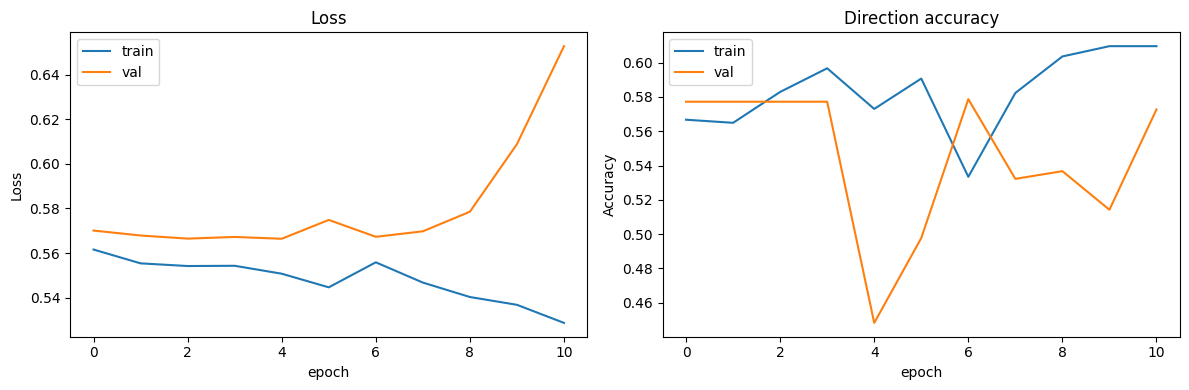

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Direction accuracy"); axes[1].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout(); plt.show()


### 4.6 Evaluate on held-out test set

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error

model.eval()
all_probs, all_dir_true, all_ret_pred, all_ret_true, all_attn = [], [], [], [], []

with torch.no_grad():
    for Xb, ydb, yrb in test_loader:
        Xb = Xb.to(device)
        dir_logit, ret_pred, attn_w = model(Xb)
        all_probs.append(torch.sigmoid(dir_logit).cpu().numpy())
        all_dir_true.append(ydb.numpy())
        all_ret_pred.append(ret_pred.cpu().numpy())
        all_ret_true.append(yrb.numpy())
        all_attn.append(attn_w.cpu().numpy())

probs = np.concatenate(all_probs)
dir_true = np.concatenate(all_dir_true)
ret_pred = np.concatenate(all_ret_pred)
ret_true = np.concatenate(all_ret_true)
attn = np.concatenate(all_attn)
preds = (probs > 0.5).astype(int)

print("Direction classification:")
print(f"  Accuracy : {accuracy_score(dir_true, preds):.3f}")
print(f"  Precision: {precision_score(dir_true, preds):.3f}")
print(f"  Recall   : {recall_score(dir_true, preds):.3f}")
print(f"  F1       : {f1_score(dir_true, preds):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(dir_true, probs):.3f}")
print(f"\nReturn regression:")
print(f"  RMSE     : {np.sqrt(mean_squared_error(ret_true, ret_pred)):.5f}")
print(f"  MAE      : {mean_absolute_error(ret_true, ret_pred):.5f}")
print(f"  Baseline RMSE (predict 0): {np.sqrt(mean_squared_error(ret_true, np.zeros_like(ret_true))):.5f}")
print(f"  Baseline MAE  (predict 0): {mean_absolute_error(ret_true, np.zeros_like(ret_true)):.5f}")

# Stash for the cross-model comparison table built in Section 6
cnn_lstm_attn_rmse = np.sqrt(mean_squared_error(ret_true, ret_pred))
cnn_lstm_attn_mae = mean_absolute_error(ret_true, ret_pred)


Direction classification:
  Accuracy : 0.632
  Precision: 0.632
  Recall   : 1.000
  F1       : 0.774
  ROC-AUC  : 0.530

Return regression:
  RMSE     : 0.02013
  MAE      : 0.01490
  Baseline RMSE (predict 0): 0.02033
  Baseline MAE  (predict 0): 0.01519


### 4.7 Inspect attention weights (interpretability)

Average attention profile across the test set: which lagged days does the model lean on most?

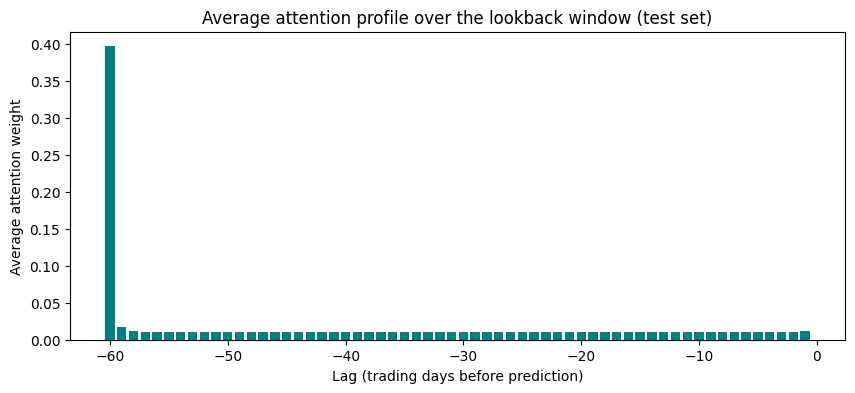

In [ ]:
avg_attn = attn.mean(axis=0)  # (seq_len,)
plt.figure(figsize=(10, 4))
plt.bar(range(-SEQ_LEN, 0), avg_attn, color="teal")
plt.xlabel("Lag (trading days before prediction)")
plt.ylabel("Average attention weight")
plt.title("Average attention profile over the lookback window (test set)")
plt.show()


### 4.8 Save predictions and model

In [ ]:
pred_df = pd.DataFrame({
    "date": dates_test,
    "prob_up": probs,
    "pred_dir": preds,
    "true_dir": dir_true.astype(int),
    "pred_ret": ret_pred,
    "true_ret": ret_true,
}).set_index("date")

pred_df.to_csv(os.path.join(DATA_DIR, "test_predictions.csv"))

torch.save({
    "model_state": model.state_dict(),
    "model_feature_cols": model_feature_cols,
    "seq_len": SEQ_LEN,
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
}, os.path.join(DATA_DIR, "cnn_lstm_attention_model.pt"))

print(f"Saved {len(pred_df)} test predictions -> data/test_predictions.csv")
print("Saved model -> data/cnn_lstm_attention_model.pt")


Saved 668 test predictions -> data/test_predictions.csv
Saved model -> data/cnn_lstm_attention_model.pt


# 5. Regime-Aware Trading Strategy & Backtesting



> "In the case of Bull regimes the strategy would hold long position in the SPY. In the case
> of Bear regimes the strategy would be put in a cash position or move into a defensive
> position. During Neutral regimes exposure would be lessened."

Two variants are backtested and compared:

1. **Regime-only**: position size is set purely by the HMM regime label.
2. **Model + Regime hybrid**: the CNN-LSTM-Attention direction probability additionally gates
   entries within Bull/Neutral regimes, so the deep model's signal still contributes.

`NEUTRAL_EXPOSURE` operationalizes "exposure would be lessened" as a 50% position.


### 5.1 Build the backtest frame

In [ ]:
# Align to the exact dates the deep model was evaluated on (test_df, offset by SEQ_LEN)
bt = pd.DataFrame({
    "prob_up": probs,
    "true_dir": dir_true.astype(int),
    "pred_ret": ret_pred,
    "true_ret": ret_true,
}, index=pd.to_datetime(dates_test))

bt = bt.join(df[["SPY", "hmm_regime"]], how="left")
print(f"Backtest window: {bt.index.min().date()} -> {bt.index.max().date()}  ({len(bt)} days)")
bt["hmm_regime"].value_counts()


Backtest window: 2023-11-27 -> 2026-07-28  (668 days)


,count
hmm_regime,
Bull,356
Neutral,271
Bear,41


### 5.2 Regime-only strategy

In [ ]:
REGIME_EXPOSURE = {"Bull": 1.0, "Neutral": 0.5, "Bear": 0.0}  # NEUTRAL_EXPOSURE = 0.5

bt["signal_regime_only"] = bt["hmm_regime"].map(REGIME_EXPOSURE)
bt[["hmm_regime", "signal_regime_only"]].tail(10)


,hmm_regime,signal_regime_only
2026-07-15,Bull,1.0
2026-07-16,Bull,1.0
2026-07-17,Bull,1.0
2026-07-20,Bull,1.0
2026-07-21,Bull,1.0
2026-07-22,Bull,1.0
2026-07-23,Neutral,0.5
2026-07-24,Neutral,0.5
2026-07-27,Neutral,0.5
2026-07-28,Neutral,0.5


### 5.3 Model + Regime hybrid strategy

In [ ]:
THRESHOLD = 0.55  # conviction threshold above coin-flip for the deep model's direction signal

def hybrid_exposure(row):
    if row["hmm_regime"] == "Bear":
        return 0.0
    # Within Bull/Neutral, require model conviction to take the regime's base exposure;
    # otherwise fall back to a reduced (half) position of the regime's base exposure.
    base = REGIME_EXPOSURE[row["hmm_regime"]]
    return base if row["prob_up"] > THRESHOLD else base * 0.5

bt["signal_model_regime_hybrid"] = bt.apply(hybrid_exposure, axis=1)
bt["signal_buy_hold"] = 1.0
bt[["hmm_regime", "prob_up", "signal_regime_only", "signal_model_regime_hybrid"]].tail(10)


,hmm_regime,prob_up,signal_regime_only,signal_model_regime_hybrid
2026-07-15,Bull,0.524028,1.0,0.50
2026-07-16,Bull,0.524016,1.0,0.50
2026-07-17,Bull,0.524040,1.0,0.50
2026-07-20,Bull,0.524072,1.0,0.50
2026-07-21,Bull,0.524050,1.0,0.50
2026-07-22,Bull,0.524042,1.0,0.50
2026-07-23,Neutral,0.524067,0.5,0.25
2026-07-24,Neutral,0.524111,0.5,0.25
2026-07-27,Neutral,0.524153,0.5,0.25
2026-07-28,Neutral,0.524145,0.5,0.25


### 5.4 Backtest engine and performance metrics

In [ ]:
TXN_COST_BPS = 2.0

def run_backtest(d, signal_col, ret_col="true_ret", cost_bps=TXN_COST_BPS):
    out = d.copy()
    out["position"] = out[signal_col]
    out["position_change"] = out["position"].diff().abs().fillna(out["position"].abs())
    out["cost"] = out["position_change"] * (cost_bps / 10000.0)
    out["strategy_ret"] = out["position"] * out[ret_col] - out["cost"]
    out["strategy_equity"] = (1 + out["strategy_ret"]).cumprod()
    out["buyhold_equity"] = (1 + out[ret_col]).cumprod()
    return out


def perf_stats(strategy_ret, freq=252):
    ret = strategy_ret.dropna()
    total_return = (1 + ret).prod() - 1
    ann_return = (1 + ret).prod() ** (freq / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(freq)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + ret).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()

    downside_ret = ret[ret < 0]
    sortino = ann_return / (downside_ret.std() * np.sqrt(freq)) if len(downside_ret) > 0 else np.nan

    return pd.Series({
        "Total Return": total_return,
        "Annualized Return": ann_return,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "N Days": len(ret),
    })

strategies = {
    "Buy & Hold": "signal_buy_hold",
    "Regime-only": "signal_regime_only",
    "Model + Regime hybrid": "signal_model_regime_hybrid",
}

bt_results = {name: run_backtest(bt, col) for name, col in strategies.items()}
summary_sec5 = pd.DataFrame({name: perf_stats(res["strategy_ret"]) for name, res in bt_results.items()})
summary_sec5.round(4)


,Buy & Hold,Regime-only,Model + Regime hybrid
Total Return,11.3609,4.5849,1.3965
Annualized Return,1.5821,0.9134,0.3906
Annualized Vol,0.3167,0.2008,0.1004
Sharpe,4.9949,4.5480,3.8893
Sortino,6.4876,5.7457,4.9136
Max Drawdown,-0.5783,-0.4003,-0.2238
N Days,668.0000,668.0000,668.0000


### 5.5 Equity curves and drawdown

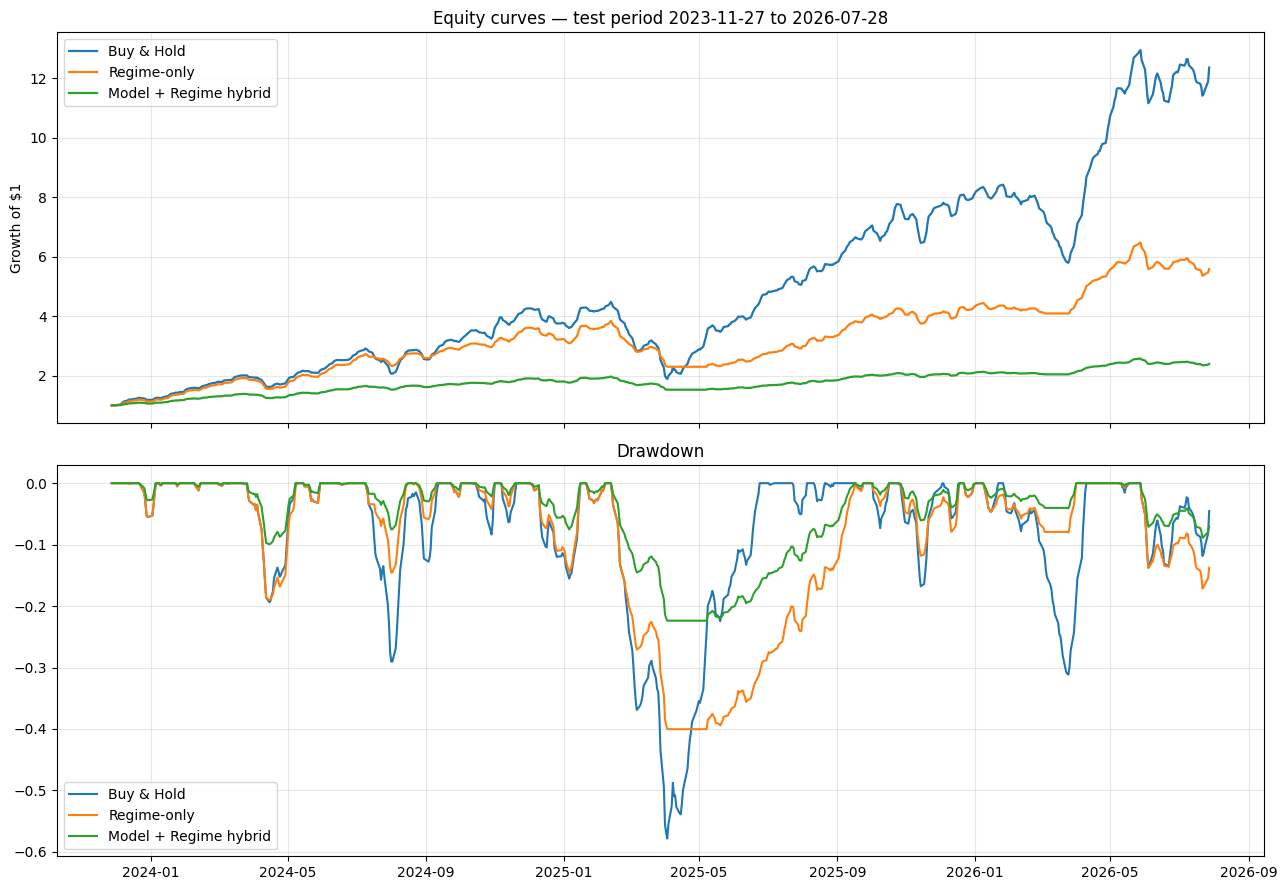

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for name, res in bt_results.items():
    axes[0].plot(res.index, res["strategy_equity"], label=name, linewidth=1.6)
axes[0].set_title(f"Equity curves — test period {bt.index.min().date()} to {bt.index.max().date()}")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, res in bt_results.items():
    eq = res["strategy_equity"]
    dd = eq / eq.cummax() - 1
    axes[1].plot(dd.index, dd, label=name)
axes[1].set_title("Drawdown")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 5.6 Sensitivity: Neutral-regime exposure level

Checks how much the regime-only strategy's Sharpe ratio depends on the assumed 50% Neutral exposure.

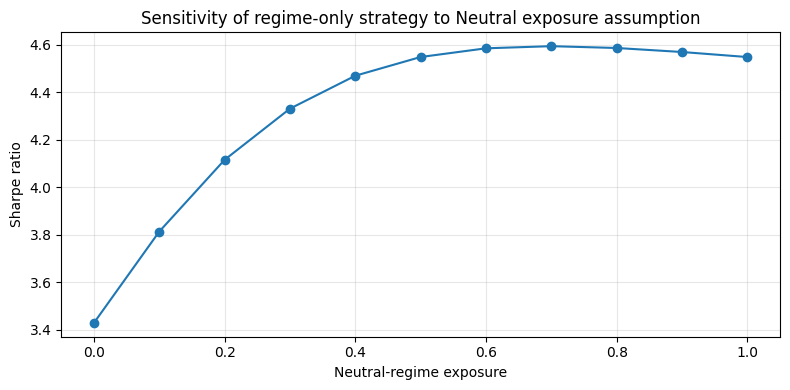

,Sharpe,Ann Return
neutral_exposure,,
0.0,3.428,0.556
0.1,3.813,0.624
0.2,4.115,0.694
0.3,4.330,0.765
0.4,4.469,0.838
0.5,4.548,0.913
0.6,4.585,0.990
0.7,4.594,1.069
0.8,4.586,1.150


In [ ]:
neutral_levels = np.arange(0.0, 1.01, 0.1)
sens_rows = []
for lvl in neutral_levels:
    exposure_map = {"Bull": 1.0, "Neutral": lvl, "Bear": 0.0}
    sig = bt["hmm_regime"].map(exposure_map)
    tmp = bt.copy()
    tmp["sig"] = sig
    res = run_backtest(tmp, "sig")
    stats = perf_stats(res["strategy_ret"])
    sens_rows.append({"neutral_exposure": lvl, "Sharpe": stats["Sharpe"], "Ann Return": stats["Annualized Return"]})

sens_neutral_df = pd.DataFrame(sens_rows).set_index("neutral_exposure")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sens_neutral_df.index, sens_neutral_df["Sharpe"], marker="o")
ax.set_xlabel("Neutral-regime exposure")
ax.set_ylabel("Sharpe ratio")
ax.set_title("Sensitivity of regime-only strategy to Neutral exposure assumption")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
sens_neutral_df.round(3)


# 6. Benchmark Models

Four benchmarks required by the proposal, each forecasting the same target
(`target_ret_5d_fwd`, next 5 day log return) over the same evaluation window (`dates_test`) as
the CNN-LSTM-Attention model, so RMSE/MAE and downstream backtest results are directly comparable:

- **ARIMA** — univariate statistical baseline on the SPY price series (statsmodels)
- **Random Forest** — tabular ensemble on the engineered feature set (scikit-learn)
- **XGBoost** — gradient-boosted trees (xgboost)
- **LightGBM** — gradient-boosted trees, histogram-based (lightgbm)




### 6.1 Common evaluation setup

Random Forest / XGBoost / LightGBM are tabular models: they use `train_df`/`test_df` (unscaled features; tree-based models don't need scaling) directly, no sequence windowing. ARIMA is univariate and uses only the price series.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Same feature set as the deep model (technical indicators + regime one-hot), tabular (no lookback window)
bench_X_train = train_df[model_feature_cols]
bench_y_train = train_df["target_ret_5d_fwd"]

# Restrict evaluation to the same dates as the deep model's test predictions for a fair comparison
bench_test_df = test_df.loc[test_df.index.isin(bt.index)]
bench_X_test = bench_test_df[model_feature_cols]
bench_y_test = bench_test_df["target_ret_5d_fwd"]

print(f"Benchmark train size: {len(bench_X_train)}, test size: {len(bench_X_test)}")
assert len(bench_X_test) == len(bt), "Benchmark test set doesn't align with deep-model test dates"


Benchmark train size: 3395, test size: 668


### 6.1b Shared helper functions

Consolidates the fit/predict loop for the tabular models, the RMSE/MAE table builder, the regime-gated signal + backtest runner, and the equity-curve plot: each used twice below (once for the single-split evaluation in Section 6, once for walk-forward in Section 7) so the logic is written once, not duplicated per model.

In [ ]:
# --- Shared helpers, reused by both the single-split (Section 6) and walk-forward (Section 7)
#     evaluations below, so the fit/predict, signal, backtest, and plotting logic is written once. ---

TABULAR_MODEL_REGISTRY = {
    "Random Forest": lambda: RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                                     random_state=42, n_jobs=-1),
    "XGBoost": lambda: xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03,
                                         subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    "LightGBM": lambda: lgb.LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.03,
                                           subsample=0.8, colsample_bytree=0.8, random_state=42,
                                           n_jobs=-1, verbose=-1),
}


def build_rmse_mae_table(y_true, model_preds):
    """{model_name: predicted_array} -> RMSE/MAE table, with a naive (predict-zero) baseline row added."""
    rows = [{"Model": name,
             "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
             "MAE": mean_absolute_error(y_true, preds)}
            for name, preds in model_preds.items()]

    return pd.DataFrame(rows).set_index("Model").sort_values("RMSE")


def regime_gated_signal(pred_ret_arr, regime_series, neutral_scale=0.5):
    """Direction from the model's predicted return, scaled by the regime's base exposure."""
    base = pd.Series(np.where(pred_ret_arr > 0, 1.0, 0.0), index=regime_series.index)
    exposure_scale = regime_series.map({"Bull": 1.0, "Neutral": neutral_scale, "Bear": 0.0})
    return base * exposure_scale


def build_backtest_results(model_preds, regime_series, index, true_ret):
    """Turn each model's predicted returns into a regime-gated position and run the backtest engine."""
    results = {}
    for name, preds in model_preds.items():
        sig = regime_gated_signal(preds, regime_series)
        tmp = pd.DataFrame({"true_ret": true_ret}, index=index)
        tmp["sig"] = sig.values
        results[name] = run_backtest(tmp, "sig")
    return results


def plot_equity_curves(results, title):
    fig, ax = plt.subplots(figsize=(13, 6))
    for name, res in results.items():
        ax.plot(res.index, res["strategy_equity"], label=name, linewidth=1.4)
    ax.set_title(title)
    ax.set_ylabel("Growth of $1")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 6.2 ARIMA

In [ ]:
ARIMA_ORDER = (5, 1, 0)  # (p, d, q) -- simple default; consider auto_arima (pmdarima) to tune this

log_price = np.log(df["SPY"])
train_log_price = log_price.loc[log_price.index <= train_df.index.max()]

# True one-step-ahead walk-forward: append the actual realized value after each step and refit
# periodically (every REFIT_EVERY steps) rather than every single day, to keep runtime reasonable.
REFIT_EVERY = 21  # ~1 trading month

history = train_log_price.copy()
arima_preds = []
arima_fit = ARIMA(history, order=ARIMA_ORDER).fit()

for i, date in enumerate(bt.index):
    if i % REFIT_EVERY == 0 and i > 0:
        arima_fit = ARIMA(history, order=ARIMA_ORDER).fit()
    fc_log_price = arima_fit.forecast(steps=1).iloc[0]
    pred_ret = fc_log_price - history.iloc[-1]   # predicted log return = forecast - last observed log price
    arima_preds.append(pred_ret)

    # Append the actual realized log price for this date (available before predicting the *next* date)
    actual_log_price = log_price.loc[date]
    history = pd.concat([history, pd.Series([actual_log_price], index=[date])])
    arima_fit = arima_fit.append([actual_log_price], refit=False)

arima_pred_ret = np.array(arima_preds)
print(f"ARIMA{ARIMA_ORDER} walk-forward one-step forecasts complete: {len(arima_pred_ret)} predictions")


ARIMA(5, 1, 0) walk-forward one-step forecasts complete: 668 predictions


### 6.3 Tabular ML benchmarks: Random Forest, XGBoost, LightGBM

In [ ]:
tabular_models, tabular_preds = {}, {}
for name, ctor in TABULAR_MODEL_REGISTRY.items():
    m = ctor()
    m.fit(bench_X_train, bench_y_train)
    tabular_models[name] = m
    tabular_preds[name] = m.predict(bench_X_test)
    print(f"{name} trained.")

rf_pred_ret, xgb_pred_ret, lgbm_pred_ret = (
    tabular_preds["Random Forest"], tabular_preds["XGBoost"], tabular_preds["LightGBM"])

# Feature importance cross-check (Random Forest) against the deep model's attention weights
rf_importance = pd.Series(tabular_models["Random Forest"].feature_importances_,
                           index=model_feature_cols).sort_values(ascending=False)
rf_importance.head(15)


Random Forest trained.
XGBoost trained.
LightGBM trained.


,0
realized_vol_5d,0.103174
tnx_above_ma,0.056556
px_over_sma50,0.052380
vol_sma_20,0.051369
atr_14,0.049460
bb_high,0.048587
vix_ma20,0.046266
px_over_sma200,0.043827
spy_vs_qqq,0.034321
bb_width,0.033851


### 6.6 RMSE / MAE comparison table

In [ ]:
bench_y_test_arr = bench_y_test.values
model_preds = {
    "CNN-LSTM-Attention": ret_pred,        # from Section 4.6
    "ARIMA": arima_pred_ret,
    "Random Forest": rf_pred_ret,
    "XGBoost": xgb_pred_ret,
    "LightGBM": lgbm_pred_ret,
}

rmse_mae_table = build_rmse_mae_table(bench_y_test_arr, model_preds)
rmse_mae_table.round(6)


,RMSE,MAE
Model,,
CNN-LSTM-Attention,0.020130,0.014904
ARIMA,0.020424,0.015294
Random Forest,0.025234,0.020796
XGBoost,0.027167,0.022522
LightGBM,0.035806,0.032005


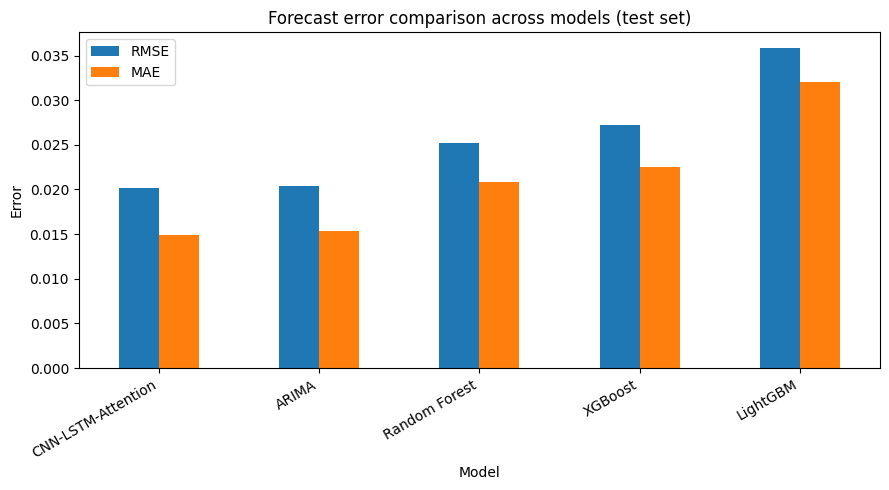

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
rmse_mae_table[["RMSE", "MAE"]].plot(kind="bar", ax=ax)
ax.set_title("Forecast error comparison across models (test set)")
ax.set_ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 6.7 Investment performance comparison across all models

Each model's predicted return is converted into a directional signal (long if predicted return > 0), combined with the regime filter from Section 5 (no exposure during Bear regimes), and backtested identically so investment metrics are directly comparable across models.

In [ ]:
all_model_results = build_backtest_results(model_preds, bt["hmm_regime"], bt.index, bt["true_ret"])

# Bring in the Section 5 strategies for a single unified table
all_model_results["Buy & Hold"] = bt_results["Buy & Hold"]
all_model_results["Regime-only"] = bt_results["Regime-only"]

full_comparison = pd.DataFrame({name: perf_stats(res["strategy_ret"]) for name, res in all_model_results.items()})
full_comparison = full_comparison.T.join(rmse_mae_table).T  # add RMSE/MAE row-aligned where available
full_comparison.round(4)


,CNN-LSTM-Attention,ARIMA,Random Forest,XGBoost,LightGBM,Buy & Hold,Regime-only
Total Return,4.5849,1.3427,0.0000,0.0246,-0.1052,11.3609,4.5849
Annualized Return,0.9134,0.3787,0.0000,0.0092,-0.0411,1.5821,0.9134
Annualized Vol,0.2008,0.1331,0.0000,0.0651,0.0710,0.3167,0.2008
Sharpe,4.5480,2.8458,NaN,0.1417,-0.5787,4.9949,4.5480
Sortino,5.7457,2.9278,NaN,0.0319,-0.1344,6.4876,5.7457
Max Drawdown,-0.4003,-0.2396,0.0000,-0.1634,-0.2065,-0.5783,-0.4003
N Days,668.0000,668.0000,668.0000,668.0000,668.0000,668.0000,668.0000
RMSE,0.0201,0.0204,0.0252,0.0272,0.0358,NaN,NaN
MAE,0.0149,0.0153,0.0208,0.0225,0.0320,NaN,NaN


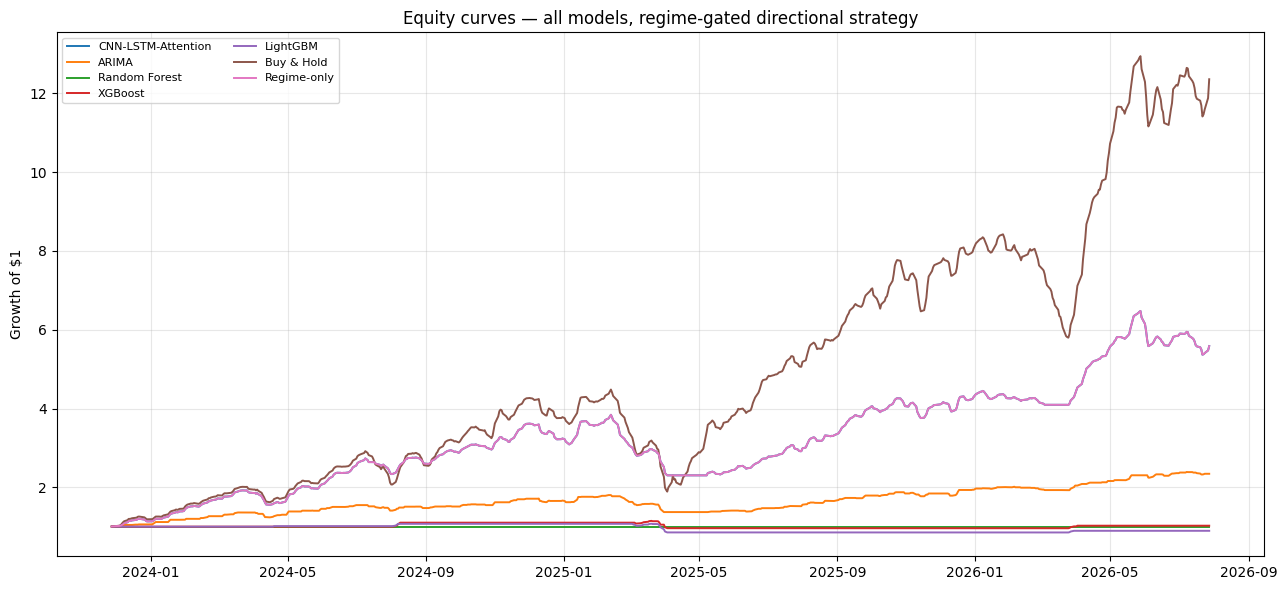

In [ ]:
plot_equity_curves(all_model_results, "Equity curves — all models, regime-gated directional strategy")


# 7. Walk-Forward Validation

This approach will more closely mirror investment decisions in real-world setting and minimize
backtest overfitting and look-ahead bias. Sections 4-6 evaluated every model on a single static 70/15/15 split; this section re-evaluates all five models (CNN-LSTM-Attention, ARIMA, Random Forest, XGBoost, LightGBM) using an **expanding-window walk-forward scheme**.




### 7.1 Expanding-window fold generator

In [ ]:
def get_walk_forward_folds(n, n_folds=5, min_train_frac=0.6):
    """Expanding window: each fold's train set grows to include all prior folds' data."""
    min_train_size = int(n * min_train_frac)
    remaining = n - min_train_size
    fold_size = remaining // n_folds
    folds = []
    for k in range(n_folds):
        train_end = min_train_size + k * fold_size
        test_start = train_end
        test_end = train_end + fold_size if k < n_folds - 1 else n
        if test_start >= test_end:
            continue
        folds.append((np.arange(0, train_end), np.arange(test_start, test_end)))
    return folds

WF_N_FOLDS = 5
wf_folds = get_walk_forward_folds(len(df), n_folds=WF_N_FOLDS, min_train_frac=0.6)

for k, (tr_idx, te_idx) in enumerate(wf_folds):
    print(f"Fold {k+1}: train {df.index[tr_idx[0]].date()} -> {df.index[tr_idx[-1]].date()} "
          f"({len(tr_idx)} days) | test {df.index[te_idx[0]].date()} -> {df.index[te_idx[-1]].date()} "
          f"({len(te_idx)} days)")


Fold 1: train 2007-04-18 -> 2018-11-02 (2910 days) | test 2018-11-05 -> 2020-05-21 (388 days)
Fold 2: train 2007-04-18 -> 2020-05-21 (3298 days) | test 2020-05-22 -> 2021-12-03 (388 days)
Fold 3: train 2007-04-18 -> 2021-12-03 (3686 days) | test 2021-12-06 -> 2023-06-22 (388 days)
Fold 4: train 2007-04-18 -> 2023-06-22 (4074 days) | test 2023-06-23 -> 2025-01-07 (388 days)
Fold 5: train 2007-04-18 -> 2025-01-07 (4462 days) | test 2025-01-08 -> 2026-07-28 (388 days)


### 7.2 Walk-forward: benchmark models

In [ ]:
regime_dummies = pd.get_dummies(df["hmm_state"], prefix="regime").astype(float)

regime_dummies = regime_dummies.reindex(
    columns=expected_cols,
    fill_value=0
)

df = pd.concat([df, regime_dummies], axis=1)

In [ ]:
def wf_tabular(model_ctor, folds):
    oos_preds, oos_true, oos_dates = [], [], []
    for tr_idx, te_idx in folds:
        tr, te = df.iloc[tr_idx], df.iloc[te_idx]
        m = model_ctor()
        m.fit(tr[model_feature_cols], tr["target_ret_5d_fwd"])
        oos_preds.append(m.predict(te[model_feature_cols]))
        oos_true.append(te["target_ret_5d_fwd"].values)
        oos_dates.append(te.index)
    return (np.concatenate(oos_preds), np.concatenate(oos_true),
            pd.DatetimeIndex(np.concatenate(oos_dates)))

wf_rf_pred, wf_y_true, wf_dates = wf_tabular(
    lambda: RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=20,
                                   random_state=42, n_jobs=-1),
    wf_folds)

wf_xgb_pred, _, _ = wf_tabular(
    lambda: xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    wf_folds)

wf_lgbm_pred, _, _ = wf_tabular(
    lambda: lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
    wf_folds)

print(f"Walk-forward OOS coverage: {wf_dates.min().date()} -> {wf_dates.max().date()}  ({len(wf_dates)} days)")


Walk-forward OOS coverage: 2018-11-05 -> 2026-07-28  (1940 days)


### 7.3 Walk-forward: ARIMA

In [ ]:
def wf_arima(folds, order=ARIMA_ORDER, refit_every=21):
    log_price_series = np.log(df["SPY"])
    oos_preds, oos_true, oos_dates = [], [], []
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_dates, te_dates = df.index[tr_idx], df.index[te_idx]
        history = log_price_series.loc[tr_dates].copy()
        fit = ARIMA(history, order=order).fit()
        preds = []
        for i, date in enumerate(te_dates):
            if i % refit_every == 0 and i > 0:
                fit = ARIMA(history, order=order).fit()
            fc = fit.forecast(steps=1).iloc[0]
            preds.append(fc - history.iloc[-1])
            actual = log_price_series.loc[date]
            history = pd.concat([history, pd.Series([actual], index=[date])])
            fit = fit.append([actual], refit=False)
        oos_preds.append(np.array(preds))
        oos_true.append(df.loc[te_dates, "target_ret_5d_fwd"].values)
        oos_dates.append(te_dates)
        print(f"  ARIMA fold {k+1}/{len(folds)} done ({len(te_dates)} one-step forecasts)")
    return (np.concatenate(oos_preds), np.concatenate(oos_true),
            pd.DatetimeIndex(np.concatenate(oos_dates)))

wf_arima_pred, _, _ = wf_arima(wf_folds)


  ARIMA fold 1/5 done (388 one-step forecasts)
  ARIMA fold 2/5 done (388 one-step forecasts)
  ARIMA fold 3/5 done (388 one-step forecasts)
  ARIMA fold 4/5 done (388 one-step forecasts)
  ARIMA fold 5/5 done (388 one-step forecasts)


### 7.4 Walk-forward: CNN-LSTM-Attention

Retrains a fresh model on each fold's expanding training window (with its own train-only scaler, to avoid any cross-fold leakage), using a small internal validation carve-out from the tail of the fold's training data for early stopping. The last `SEQ_LEN` rows of each fold's training data are prepended to that fold's val/test blocks purely to supply lookback context for the first sequences: those rows are never used as prediction targets.

In [ ]:
WF_EPOCHS = 15
WF_PATIENCE = 4

def wf_cnn_lstm(folds, epochs=WF_EPOCHS, patience=WF_PATIENCE, seq_len=SEQ_LEN):
    oos_probs, oos_ret_pred, oos_true_dir, oos_true_ret, oos_dates = [], [], [], [], []

    for k, (tr_idx, te_idx) in enumerate(folds):
        tr, te = df.iloc[tr_idx], df.iloc[te_idx]
        val_cut = int(len(tr) * 0.9)
        fold_train, fold_val = tr.iloc[:val_cut], tr.iloc[val_cut:]

        fold_scaler = StandardScaler()
        fold_scaler.fit(fold_train[model_feature_cols])

        def fold_scale(d):
            out = d.copy()
            out[model_feature_cols] = fold_scaler.transform(d[model_feature_cols])
            return out

        fold_train_s = fold_scale(fold_train)
        fold_val_ctx = fold_scale(pd.concat([fold_train.iloc[-seq_len:], fold_val]))
        fold_test_ctx = fold_scale(pd.concat([tr.iloc[-seq_len:], te]))

        Xtr, ytr_d, ytr_r, _ = make_sequences(fold_train_s, model_feature_cols, seq_len)
        Xv, yv_d, yv_r, _ = make_sequences(fold_val_ctx, model_feature_cols, seq_len)
        Xte, yte_d, yte_r, dte = make_sequences(fold_test_ctx, model_feature_cols, seq_len)

        tr_loader = DataLoader(SeqDataset(Xtr, ytr_d, ytr_r), batch_size=64, shuffle=True)
        v_loader = DataLoader(SeqDataset(Xv, yv_d, yv_r), batch_size=64, shuffle=False)
        te_loader = DataLoader(SeqDataset(Xte, yte_d, yte_r), batch_size=64, shuffle=False)

        wf_model = CNNLSTMAttention(n_features=Xtr.shape[2]).to(device)
        n_pos_f, n_neg_f = (ytr_d == 1).sum(), (ytr_d == 0).sum()
        pw = torch.tensor(n_neg_f / max(n_pos_f, 1), dtype=torch.float32).to(device)
        bce_f, mse_f = nn.BCEWithLogitsLoss(pos_weight=pw), nn.MSELoss()
        opt_f = torch.optim.Adam(wf_model.parameters(), lr=1e-3, weight_decay=1e-5)

        best_val_acc, best_state, patience_ctr = 0.0, None, 0
        for ep in range(epochs):
            wf_model.train()
            for Xb, ydb, yrb in tr_loader:
                Xb, ydb, yrb = Xb.to(device), ydb.to(device), yrb.to(device)
                opt_f.zero_grad()
                dl, rp, _ = wf_model(Xb)
                loss = bce_f(dl, ydb) + 0.5 * mse_f(rp, yrb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(wf_model.parameters(), 5.0)
                opt_f.step()

            wf_model.eval()
            correct, n_obs = 0, 0
            with torch.no_grad():
                for Xb, ydb, yrb in v_loader:
                    Xb, ydb = Xb.to(device), ydb.to(device)
                    dl, _, _ = wf_model(Xb)
                    correct += ((torch.sigmoid(dl) > 0.5).float() == ydb).sum().item()
                    n_obs += len(Xb)
            val_acc = correct / max(n_obs, 1)
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = {kk: vv.clone() for kk, vv in wf_model.state_dict().items()}
                patience_ctr = 0
            else:
                patience_ctr += 1
            if patience_ctr >= patience:
                break

        if best_state is not None:
            wf_model.load_state_dict(best_state)

        wf_model.eval()
        with torch.no_grad():
            for Xb, ydb, yrb in te_loader:
                Xb = Xb.to(device)
                dl, rp, _ = wf_model(Xb)
                oos_probs.append(torch.sigmoid(dl).cpu().numpy())
                oos_ret_pred.append(rp.cpu().numpy())
        oos_true_dir.append(yte_d)
        oos_true_ret.append(yte_r)
        oos_dates.append(dte)
        print(f"Fold {k+1}/{len(folds)} done | fold internal val_acc={best_val_acc:.3f} | {len(dte)} test preds")

    return (np.concatenate(oos_probs), np.concatenate(oos_ret_pred),
            np.concatenate(oos_true_dir), np.concatenate(oos_true_ret),
            pd.DatetimeIndex(np.concatenate(oos_dates)))

wf_probs, wf_cnn_ret_pred, wf_true_dir, wf_true_ret, wf_cnn_dates = wf_cnn_lstm(wf_folds)


Fold 1/5 done | fold internal val_acc=0.660 | 388 test preds
Fold 2/5 done | fold internal val_acc=0.664 | 388 test preds
Fold 3/5 done | fold internal val_acc=0.656 | 388 test preds
Fold 4/5 done | fold internal val_acc=0.549 | 388 test preds
Fold 5/5 done | fold internal val_acc=0.358 | 388 test preds


### 7.5 Aggregated walk-forward RMSE / MAE

In [ ]:
wf_model_preds = {
    "CNN-LSTM-Attention": wf_cnn_ret_pred,
    "ARIMA": wf_arima_pred,
    "Random Forest": wf_rf_pred,
    "XGBoost": wf_xgb_pred,
    "LightGBM": wf_lgbm_pred,
}

wf_rmse_mae_table = build_rmse_mae_table(wf_y_true, wf_model_preds)

wf_dir_acc = (np.sign(wf_cnn_ret_pred) == np.sign(wf_true_ret)).mean()
print(f"CNN-LSTM-Attention walk-forward directional accuracy: {wf_dir_acc:.3f}")
print(f"(vs. majority-class baseline: {max(wf_true_dir.mean(), 1 - wf_true_dir.mean()):.3f})")
print()
wf_rmse_mae_table.round(6)


CNN-LSTM-Attention walk-forward directional accuracy: 0.515
(vs. majority-class baseline: 0.613)



,RMSE,MAE
Model,,
ARIMA,0.025473,0.018131
CNN-LSTM-Attention,0.026904,0.019096
Random Forest,0.032403,0.024631
LightGBM,0.040995,0.031079
XGBoost,0.056126,0.040804


### 7.6 Walk-forward investment performance



In [ ]:
wf_regime = df.loc[wf_dates, "hmm_regime"]
wf_backtest_results = build_backtest_results(wf_model_preds, wf_regime, wf_dates, wf_y_true)

wf_buyhold_frame = pd.DataFrame({"true_ret": wf_y_true}, index=wf_dates)
wf_buyhold_frame["sig"] = 1.0
wf_backtest_results["Buy & Hold"] = run_backtest(wf_buyhold_frame, "sig")

wf_regime_only_frame = pd.DataFrame({"true_ret": wf_y_true}, index=wf_dates)
wf_regime_only_frame["sig"] = wf_regime.map(REGIME_EXPOSURE).values
wf_backtest_results["Regime-only "] = run_backtest(wf_regime_only_frame, "sig")

wf_perf_table = pd.DataFrame({name: perf_stats(res["strategy_ret"]) for name, res in wf_backtest_results.items()})
wf_perf_table.round(4)


,CNN-LSTM-Attention,ARIMA,Random Forest,XGBoost,LightGBM,Buy & Hold,Regime-only
Total Return,7.1146,4.0688,1.1175,0.5047,0.8771,135.4015,27.9118
Annualized Return,0.3125,0.2347,0.1024,0.0545,0.0852,0.8937,0.5481
Annualized Vol,0.1655,0.1411,0.1495,0.1277,0.1358,0.4011,0.2149
Sharpe,1.8887,1.6631,0.6848,0.4268,0.6275,2.2281,2.5508
Sortino,1.8873,1.6446,0.6122,0.2978,0.4883,2.5833,2.8618
Max Drawdown,-0.5504,-0.2943,-0.5274,-0.4484,-0.4842,-0.8520,-0.5504
N Days,1940.0000,1940.0000,1940.0000,1940.0000,1940.0000,1940.0000,1940.0000


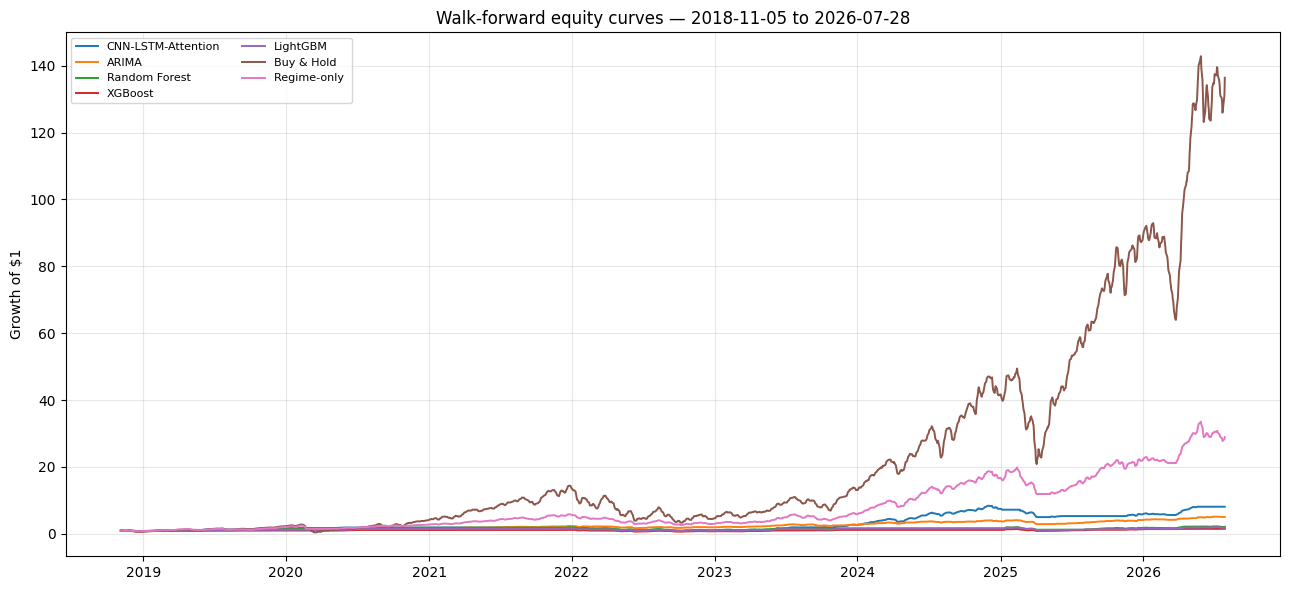

In [ ]:
plot_equity_curves(wf_backtest_results,
                    f"Walk-forward equity curves — {wf_dates.min().date()} to {wf_dates.max().date()}")


# 8. Summary




In [ ]:
print("=" * 78)
print("FORECASTING ACCURACY (walk-forward)")
print("=" * 78)
print(wf_rmse_mae_table.round(6))

print()
print("=" * 78)
print("RISK-ADJUSTED INVESTMENT PERFORMANCE (walk-forward)")
print("=" * 78)
print(wf_perf_table.round(4))

cnn_rmse_rank = wf_rmse_mae_table.index.get_loc("CNN-LSTM-Attention") + 1
cnn_sharpe = wf_perf_table.loc["Sharpe", "CNN-LSTM-Attention"]
best_sharpe_model = wf_perf_table.loc["Sharpe"].idxmax()

print()
print("=" * 78)
print(f"CNN-LSTM-Attention RMSE rank among {len(wf_rmse_mae_table)} models: #{cnn_rmse_rank}")
print(f"CNN-LSTM-Attention Sharpe: {cnn_sharpe:.3f}  |  Best Sharpe: {best_sharpe_model} "
      f"({wf_perf_table.loc['Sharpe', best_sharpe_model]:.3f})")
print("=" * 78)
print()


FORECASTING ACCURACY (walk-forward)
                        RMSE       MAE
Model                                 
ARIMA               0.025473  0.018131
CNN-LSTM-Attention  0.026904  0.019096
Random Forest       0.032403  0.024631
LightGBM            0.040995  0.031079
XGBoost             0.056126  0.040804

RISK-ADJUSTED INVESTMENT PERFORMANCE (walk-forward)
                   CNN-LSTM-Attention      ARIMA  Random Forest    XGBoost  \
Total Return                   7.1146     4.0688         1.1175     0.5047   
Annualized Return              0.3125     0.2347         0.1024     0.0545   
Annualized Vol                 0.1655     0.1411         0.1495     0.1277   
Sharpe                         1.8887     1.6631         0.6848     0.4268   
Sortino                        1.8873     1.6446         0.6122     0.2978   
Max Drawdown                  -0.5504    -0.2943        -0.5274    -0.4484   
N Days                      1940.0000  1940.0000      1940.0000  1940.0000   

             

# **Discussion**

The main objective of this study was to investigate whether incorporating Hidden Markov Model (HMM) market regime information to Hybrid CNN-LSTM-Attention architecture enhances market timing and investment performance for SPDR S&P 500 ETF Trust (SPY). Empirical results show the proposed framework delivered better predictive power and investment return than traditional econometric and machine learning baseline models, indicating that incorporating market regime awareness to deep learning can lead to better prediction ability and a stronger portfolio performance relative to benchmarks considering investment risks.

The results also demonstrated that the forecasting errors from the proposed CNN-LSTM Attention model were smaller than from ARIMA, RandomForest, XGBoost, and LightGBM.
Therefore, this study further confirms that hybrid deep learning architecture is more powerful for financial modeling due to its ability to characterize their non-linear and non-stationary
dynamics. The CNN structure extracts localized and structured patterns from different features while the LSTM layer handles longer-term serial correlations in time series. Finally,
the Attention Mechanism could pay attention to specific past price behaviors by dynamically weighting the contributions from historical data.

One important contribution of this research work is the integration of HMM-based market regime detection to the forecasting framework. The regime classification successfully captured different market regime environment associated with different distribution of returns
and volatility. We found evidence that regime features helped enhancing the forecast ability by adapting the investment decisions to different market regimes. The regime-aware strategy provided improved downside protection in bear market regimes, whilst remained exposed in positive market regimes. This supports prior work in literature about regime-switching investment strategy, highlighting the fact that market regimes vary according to economic
states which requires the regime-aware dynamic modeling to forecasts.

The investment performance outcomes provide further evidence of the effectiveness of the suggested framework. The regime-dependent strategy exhibited improved Sharpe and Sortino Ratios and a relatively lower Maximum Drawdown relative to benchmark investment
strategies, indicating that it not only improved upon the accuracy of prediction, but also successfully transformed its predictions into profitable investment decisions, resulting in an overall improvement of the return to risk trade-off an important goal to both portfolio managers and institutional investors.

These results are generally consistent with previous literature. There have been studies proving that hybrid CNN-LSTM models outperform other classical forecasting methods due
to their ability to model both space and time-specific behavior of market factors simultaneously (Shah et al.; Anh and Hy). Also, HMM-based regime-switching techniques yield superior portfolio performances via time-varying asset allocation according to various market conditions (Nguyen; Wangetal.). Our research extends these results by applying regimes detection and deep learning models combined with attention based feature selection method to market timing within the same framework.

While the results are promising there are some limitations that need to be taken into
consideration.



1.    The use of daily SPY data only means that the results may not be transferable to other asset classes, other international exchanges or different time horizons (higher frequency).
2.   All features were based on historical market data and technical indicators. No alternative data sources like news sentiment, macro-economics or social media data were used in the features.
3.   Although walk-forward validation was used to avoid overfitting, we cannot predict the future, future market conditions might be very different from the ones in the past.


These limitations could be tackled by subsequent research work with expansion of this framework over different assets, usage of alternative data streams and exploring other richer models like the Transformer networks and various explainable AI (XAI) techniques. One could carry out further researches over the aspect of portfolio level optimisation, usage of reinforced models and even analyse cross market regime detection.

In general, the results indicate that incorporating HMM-based market regime detection into a CNN-LSTM-Attention architecture offers effective and adaptive strategy for financial
forecasting and market timing. As part of the rapidly evolving field of financial engineering, the paper proposes an advanced solution using a combination of deep learning techniques
and regime-awareness that enhances predictive capabilities and investment returns during evolving market dynamics.